## Evaluating ALS vs. WT Ladder-Task Performance

How did measured ladder-task gait change over trial time in these ALS and WT mice?

This notebook preserves my cleaning, metric, and plotting functions from the Hengen Lab scripts. It starts with four processed crossing files. The saved outputs let a reader inspect the graphs without those files; rerunning the analysis requires the four trusted pickle files in a data/ folder beside the notebook (run from the notebook's folder).

In [1]:
from pathlib import Path
from datetime import datetime, time, timedelta
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pwlf

## 1. Loading crosses

Each all_crosses_<mouse>.pkl file contains a list of crossing dictionaries. The unmixed_touch_0x5A and unmixed_touch_0x5B fields hold the two sides' rung-touch intervals; pred_subtype holds an upstream predicted behavior label. rungTouch_obj_start is a formatted date and time string such as 2024-10-02_18-03-22. The download(a) function reads a local pickle file named by a from the data/ folder; it does not fetch data from the internet.

In [2]:
def download(a):
    # Reads a trusted pickle file from the data folder
    with (Path('data') / a).open('rb') as f:
        return pickle.load(f)

## 2. Cleaning data

The function sorts touches by start time, removes pulses lasting 80 ms or less, merges successive intervals on the same rung, and removes isolated leading or contained intervals. It keeps crossings with at least two touches on each side and rung indices in a consistent order on each side, either increasing or decreasing. Finally, it retains the behavior subtypes selected in my original analysis.

In [3]:
def clean(all_crosses):
    # Cleaning methods
    def rearrange(cd_annealing_unmixing):
        all_touches = []
        for rung_index, rung_touches in enumerate(cd_annealing_unmixing):
            for touch in rung_touches:
                start, end = touch
                all_touches.append([start, end, rung_index]) # Converts to [start_millisecond, end_millisecond, rung_index] format

        all_touches.sort(key=lambda x: x[0]) # Resort by starting timestamp of each touch
        return all_touches

    def glitch(position, threshold=80): # Keeps only touches longer than 80 ms
        cleaned = []
        for p in position:
            if p[1] - p[0] > threshold:
                cleaned.append(p)
        return cleaned

    def merge(position): # Merges successive same-rung intervals until a different rung is encountered
        merged = []
        used = [False] * len(position)

        for i in range(len(position)):
            if used[i]:
                continue
            start, end, rung = position[i]
            for j in range(i + 1, len(position)):
                next_start, next_end, next_rung = position[j]
                if next_start >= end:
                    if next_rung == rung:
                        end = max(end, next_end)
                        used[j] = True
                    else:
                        break
            merged.append([start, end, rung])
        return merged

    def footing(position): # Removes isolated leading touches and intervals contained within earlier touches
        original = len(position)
        while len(position) >= 2 and position[0][1] < position[1][0]:
            position = position[1:]

        cleaned = []
        max_end = -float('inf')
        for touch in position:
            start, end, rung = touch
            if end <= max_end:
                continue
            cleaned.append(touch)
            max_end = max(max_end, end)
        return cleaned

    def filter(positions): # Requires two touches per side and a consistent rung order on each side
        if len(positions['L']) < 2:
            return False
        if len(positions['R']) < 2:
            return False
        if sorted(positions['L'], key=lambda x: x[2]) != positions['L'] and sorted(positions['L'], key=lambda x: x[2], reverse=True) != positions['L']:
            return False
        if sorted(positions['R'], key=lambda x: x[2]) != positions['R'] and sorted(positions['R'], key=lambda x: x[2], reverse=True) != positions['R']:
            return False
        return True

    dataset = []
    for cross in all_crosses[:]: # Applying cleaning
        positions = {}

        positions['L'] = rearrange(cross["unmixed_touch_0x5A"])
        positions['L'] = glitch(positions['L'])
        positions['L-W/ADJ'] = merge(positions['L'])
        positions['L'] = footing(positions['L-W/ADJ'])

        positions['R'] = rearrange(cross["unmixed_touch_0x5B"])
        positions['R'] = glitch(positions['R'])
        positions['R-W/ADJ'] = merge(positions['R'])
        positions['R'] = footing(positions['R-W/ADJ'])

        positions['D'] = cross['rungTouch_obj_start']
        if filter(positions) and cross['pred_subtype'] in ['walk', 'bound', 'trot', 'stall and sniff', 'stretch']: #['vertical exploration', 'stall and sniff', 'stretch', 'bound', 'trot', 'walk']
            dataset.append(positions)

    return dataset

### One crossing, before and after cleaning

The main loop below saves the first crossing that passes the cleaning rule, together with its cleaned touch intervals. The plot compares the already unmixed input with the output of clean(); it does not show the earlier sensor unmixing step.

In [4]:
def plot_touch_intervals(raw_cross, cleaned_cross):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    first_touch = min(start for key in ('unmixed_touch_0x5A', 'unmixed_touch_0x5B')
                      for touches in raw_cross[key] for start, _ in touches)
    for ax, title, item in zip(
        axes, ['Before gait cleaning', 'After gait cleaning'],
        [raw_cross, cleaned_cross],
    ):
        for side, color, key in [
            ('L', 'tab:blue', 'unmixed_touch_0x5A'),
            ('R', 'tab:orange', 'unmixed_touch_0x5B'),
        ]:
            if item is raw_cross:
                intervals = [(start, end, rung)
                             for rung, touches in enumerate(item[key])
                             for start, end in touches]
            else:
                intervals = item[side]
            for interval_index, (start, end, rung) in enumerate(intervals):
                ax.hlines(rung + (0.12 if side == 'L' else -0.12),
                          (start - first_touch) / 1000,
                          (end - first_touch) / 1000, color=color, linewidth=3,
                          label=side if interval_index == 0 else None)
        ax.set_title(title)
        ax.set_xlabel('Seconds relative to first touch')
        ax.grid(alpha=0.2)
        ax.legend(title='Sensor side')
    axes[0].set_ylabel('Rung index')
    fig.tight_layout()
    plt.show()

## 3. Calculating metrics

I calculated several gait measurements to explore which might reflect changes over trial time. For example, average step speed is the mean absolute change in rung index between successive touches on the same side divided by the time between those touch starts, in rungs per second. The analyze() function below is retained from my original script.

In [5]:
def analyze(positions, i, mouse, genotype):
    metrics = {}

    metrics['id'] = mouse

    metrics['genotype'] = genotype

    metrics['duration'] = max(p[1] for p in positions['L'] + positions['R']) - min(p[0] for p in positions['L'] + positions['R']) / 1000
    metrics['average_stance_duration'] = np.mean([(((positions['L'][i+1][0] + positions['L'][i][1]) / 2) - positions['L'][i][0]) for i in range(len(positions['L'])-1)] + [(((positions['R'][i+1][0] + positions['R'][i][1]) / 2) - positions['R'][i][0]) for i in range(len(positions['R'])-1)]) / 1000
    metrics['average_stride_duration'] = np.mean([(positions['L'][i+1][0] - positions['L'][i][0]) for i in range(len(positions['L'])-1)] + [(positions['R'][i+1][0] - positions['R'][i][0]) for i in range(len(positions['R'])-1)]) / 1000
    metrics['average_step_duration'] = np.mean([(positions['L'][i][1] - positions['L'][i + 1][0]) for i in range(len(positions['L'])-1)] + [(positions['R'][i][1] - positions['R'][i + 1][0]) for i in range(len(positions['R'])-1)])

    metrics['average_duty_factor'] = np.mean([((((positions['L'][i+1][0] + positions['L'][i][1]) / 2) - positions['L'][i][0]) / (positions['L'][i+1][0] - positions['L'][i][0])) for i in range(len(positions['L'])-1) if (positions['L'][i+1][0] - positions['L'][i][0]) != 0] + [((((positions['R'][i+1][0] + positions['R'][i][1]) / 2) - positions['R'][i][0]) / (positions['R'][i+1][0] - positions['R'][i][0])) for i in range(len(positions['R'])-1) if (positions['R'][i+1][0] - positions['R'][i][0]) != 0])
    metrics['average_step_to_stride_duration'] = np.mean([(positions['L'][i][1] - positions['L'][i + 1][0]) / (positions['L'][i+1][0] - positions['L'][i][0]) for i in range(len(positions['L'])-1) if (positions['L'][i+1][0] - positions['L'][i][0]) != 0] + [(positions['R'][i][1] - positions['R'][i + 1][0]) / (positions['R'][i+1][0] - positions['R'][i][0]) for i in range(len(positions['R'])-1) if (positions['R'][i+1][0] - positions['R'][i][0]) != 0])
    metrics['average_step_length_to_stance_duration'] = np.mean([abs(positions['L'][i+1][2] - positions['L'][i][2]) / (((positions['L'][i+1][0] + positions['L'][i][1]) / 2) - positions['L'][i][0]) for i in range(len(positions['L'])-1) if (positions['L'][i+1][0] - positions['L'][i][0]) != 0] + [abs(positions['R'][i+1][2] - positions['R'][i][2]) / (((positions['R'][i+1][0] + positions['R'][i][1]) / 2) - positions['R'][i][0]) for i in range(len(positions['R'])-1) if (positions['R'][i+1][0] - positions['R'][i][0]) != 0 ]) * 1000

    metrics['total_steps'] = len(set(p[2] for p in positions['L-W/ADJ'] + positions['R-W/ADJ']))

    metrics['average_step_length'] = np.mean([abs(positions['L'][i+1][2] - positions['L'][i][2]) for i in range(len(positions['L'])-1)] + [abs(positions['R'][i+1][2] - positions['R'][i][2]) for i in range(len(positions['R'])-1)])

    metrics['average_step_speed'] = np.mean([abs(positions['L'][i+1][2] - positions['L'][i][2]) / ((positions['L'][i+1][0] - positions['L'][i][0]) / 1000) for i in range(len(positions['L'])-1) if positions['L'][i+1][0] - positions['L'][i][0] != 0] + [abs(positions['R'][i+1][2] - positions['R'][i][2]) / ((positions['R'][i+1][0] - positions['R'][i][0]) / 1000) for i in range(len(positions['R'])-1) if positions['R'][i+1][0] - positions['R'][i][0] != 0])

    metrics['gait_adjustments'] = len(positions['L-W/ADJ']) - len(positions['L']) + len(positions['R-W/ADJ']) - len(positions['R'])

    metrics['timestamp'] = positions['D']

    t = datetime.strptime(positions['D'], "%Y-%m-%d_%H-%M-%S").time()
    metrics['day_night'] = "day" if time(7, 0) <= t < time(19, 0) else "night"

    # Time of Day
    if time(7, 0) <= t < time(11, 0):
        metrics['time_of_day'] = "early_day"
    elif time(11, 0) <= t < time(15, 0):
        metrics['time_of_day'] = "mid_day"
    elif time(15, 0) <= t < time(19, 0):
        metrics['time_of_day'] = "late_day"
    elif time(19, 0) <= t < time(23, 0):
        metrics['time_of_day'] = "early_night"
    elif time(23, 0) <= t or t < time(3, 0):
        metrics['time_of_day'] = "mid_night"
    else:
        metrics['time_of_day'] = "late_night"
    metrics['trial'] = i

    return metrics

## 4. Running the processing code

For each of the four mice, the loop loads the processed crossings, applies clean(), calls analyze() on each accepted crossing, and assigns trial day and hour relative to a 07:00 boundary. It also retains one raw and cleaned crossing pair for the demonstration plot.

In [6]:
animals = [
    'all_crosses_RCC00023.pkl',  # ALS
    'all_crosses_RCC00024.pkl',  # WT
    'all_crosses_RCC00027.pkl',  # WT
    'all_crosses_RCC00028.pkl',  # ALS
]

GENOTYPE_MAP = {
    'RCC00023': 'ALS',
    'RCC00024': 'WT',
    'RCC00027': 'WT',
    'RCC00028': 'ALS',
}

measurements = [
    'average_step_speed', 'average_stance_duration',
    'average_stride_duration', 'average_step_duration',
    'average_duty_factor', 'average_step_to_stride_duration',
    'average_step_length_to_stance_duration', 'average_step_length',
    'total_steps', 'gait_adjustments',
]

all_data = []
crossing_counts = []
example = None
for a in animals[:]: # Running the actual steps in the data pipeline
    files = download(a)
    print(f'Loaded {len(files):,} crossings from {a}')
    dataset = clean(files)

    if example is None:
        for cross in files:
            accepted_example = clean([cross])
            if accepted_example:
                example = (cross, accepted_example[0])
                break

    metrics = []
    for i, positions in enumerate(dataset[:]):
        metrics.append(analyze(
            positions, i, a[12:20], GENOTYPE_MAP[a[12:20]]
        ))

    raw_start = metrics[0]['timestamp']
    dt_start = datetime.strptime(raw_start, '%Y-%m-%d_%H-%M-%S')
    if dt_start.time() < time(7, 0):
        dt_start = dt_start - timedelta(days=1)
    start_date = datetime.combine(dt_start.date(), time(7, 0))

    for m in metrics: # Grouping by different time intervals
        dt = datetime.strptime(m['timestamp'], '%Y-%m-%d_%H-%M-%S')
        delta_seconds = (dt - start_date).total_seconds()
        delta_hours = delta_seconds / 3600
        m['trial_day'] = int(delta_hours // 24)
        m['trial_hour'] = int(delta_hours)
        m['trial_second'] = int(delta_seconds)

    all_data.extend(metrics)
    crossing_counts.append({
        'mouse': a[12:20], 'genotype': GENOTYPE_MAP[a[12:20]],
        'raw': len(files), 'accepted': len(dataset),
    })
    del files, dataset

display(pd.DataFrame(crossing_counts))

Loaded 44,628 crossings from all_crosses_RCC00023.pkl


/tmp/hengen_notebook_deps/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/tmp/hengen_notebook_deps/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Loaded 55,031 crossings from all_crosses_RCC00024.pkl


Loaded 43,270 crossings from all_crosses_RCC00027.pkl


Loaded 36,254 crossings from all_crosses_RCC00028.pkl


,mouse,genotype,raw,accepted
0,RCC00023,ALS,44628,34796
1,RCC00024,WT,55031,41911
2,RCC00027,WT,43270,33038
3,RCC00028,ALS,36254,26349


### Cleaning example

One real crossing before cleaning and the touch intervals that the original cleaning function kept.

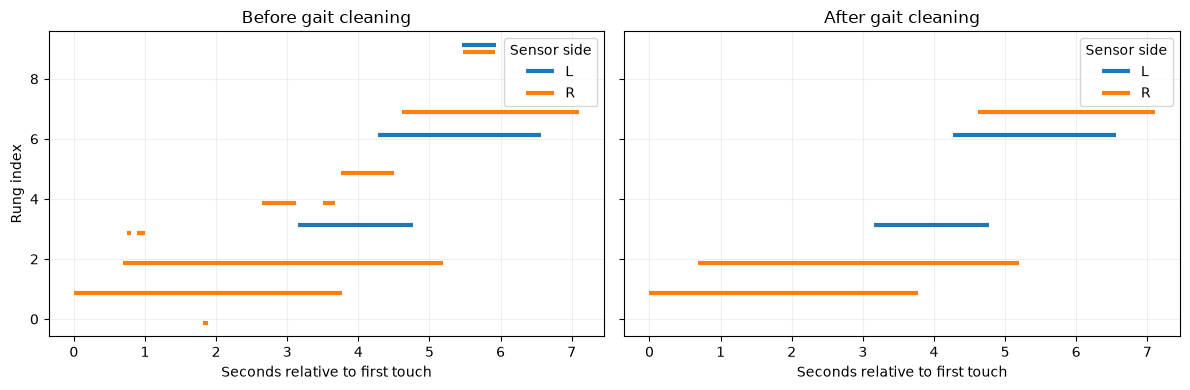

In [7]:
plot_touch_intervals(*example)

## 5. Removing metric outliers by trial day and light phase

Some crossings that pass the touch and behavior rules still have extreme calculated measurements. I apply the original 1.5×IQR filter to the ten gait measurements within each trial_day × day_night group. These bounds are calculated across the mice and genotypes represented in each group.

In [8]:
def remove_outliers(df, filter_cols, group_cols=['trial_day', 'day_night']):
    cleaned_df = pd.DataFrame()

    grouped = df.groupby(group_cols)

    for group_key, group_df in grouped: # Calculating IQR rule
        Q1 = group_df[filter_cols].quantile(0.25)
        Q3 = group_df[filter_cols].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = ~((group_df[filter_cols] < lower_bound) | (group_df[filter_cols] > upper_bound)).any(axis=1)
        cleaned_group = group_df[mask]

        cleaned_df = pd.concat([cleaned_df, cleaned_group], ignore_index=True)

    return cleaned_df

In [9]:
df = pd.DataFrame(all_data)
raw_metrics = df.copy()
print(f'Accepted crossings before IQR: {len(df):,}')
df = remove_outliers(df, measurements)
cleaned_metrics = df
print(f'After IQR: {len(df):,}')

Accepted crossings before IQR: 136,094


After IQR: 110,007


**Filtering results:** 179,183 input crossings → 136,094 after touch and behavior filtering → 110,007 after the original trial-day × day/night IQR filter. These are repeated crossings from four mice.

### Fewer crossings during the day

This table counts the retained crossings in each light phase for ALS and WT. Both groups have fewer retained crossings during the day than at night, consistent with mice being nocturnal.

In [10]:
if not cleaned_metrics.empty:
    display(pd.crosstab(cleaned_metrics['genotype'], cleaned_metrics['day_night']))

day_night,day,night
genotype,,
ALS,7919,42363
WT,10356,49369


## 6. ALS versus WT progression

I use the cleaned crossing records and restrict the plots to trial days under 80, matching the window in my original ALS/WT script. For nine of the ten measurements (excluding average step length), I fit ALS and WT separately with a two-segment piecewise-linear model using pwlf. Each fit uses the individual crossing values pooled within a genotype and estimates one breakpoint and a slope for each segment. The solid lines show the fits; the shaded bands show each genotype's daily mean ± SD.

The bootstrap routine in the original ALS/WT script is inside a triple-quoted block and does not run here. These plots contain no bootstrapped confidence intervals. With two mice per genotype and many repeated crossings, the fits are descriptive rather than an animal-level test of an ALS effect.

In [11]:
analysis_df = cleaned_metrics.loc[
    cleaned_metrics['genotype'].isin(['ALS', 'WT']) &
    (cleaned_metrics['trial_day'] < 80)
].copy()
print('Using metrics recomputed from the four pickle files.')
print(analysis_df.groupby('genotype')['id'].nunique().rename('mice'))

Using metrics recomputed from the four pickle files.
genotype
ALS    2
WT     2
Name: mice, dtype: int64


In [12]:
def fit_piecewise(genotype, n_segments):
    sub = df[df["genotype"] == genotype]
    x = sub["trial_day"].values
    y = sub[var].values

    model = pwlf.PiecewiseLinFit(x, y)
    breaks = model.fit(n_segments)

    xx = np.linspace(x.min(), x.max(), 1000)
    yy = model.predict(xx)

    sub_stats = stats[stats["genotype"] == genotype].sort_values("trial_day")
    plt.fill_between(
        sub_stats["trial_day"],
        sub_stats["mean"] - sub_stats["std"],
        sub_stats["mean"] + sub_stats["std"],
        alpha=0.15, label=f"{genotype} ± SD"
    )
    plt.plot(xx, yy, linewidth=2, label=f"{genotype} fit")

    return breaks, model.slopes

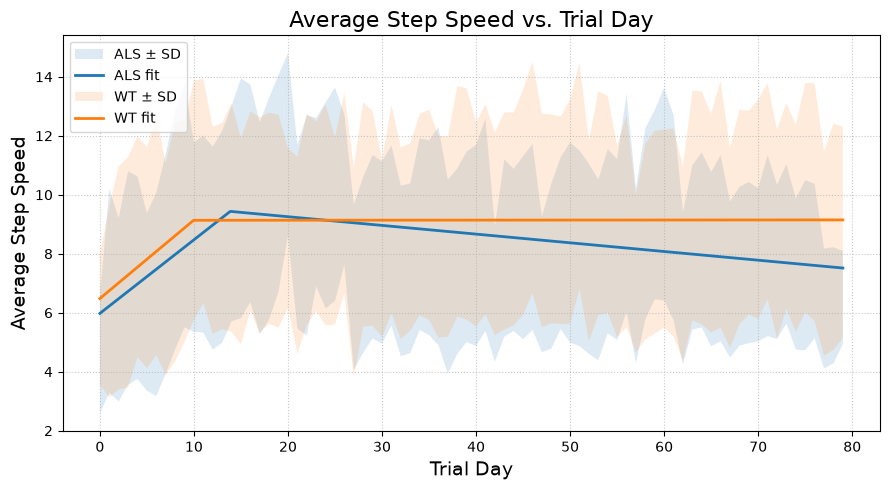

average_step_speed ALS slopes: [ 0.2496 -0.0295] WT slopes: [2.663e-01 2.000e-04]


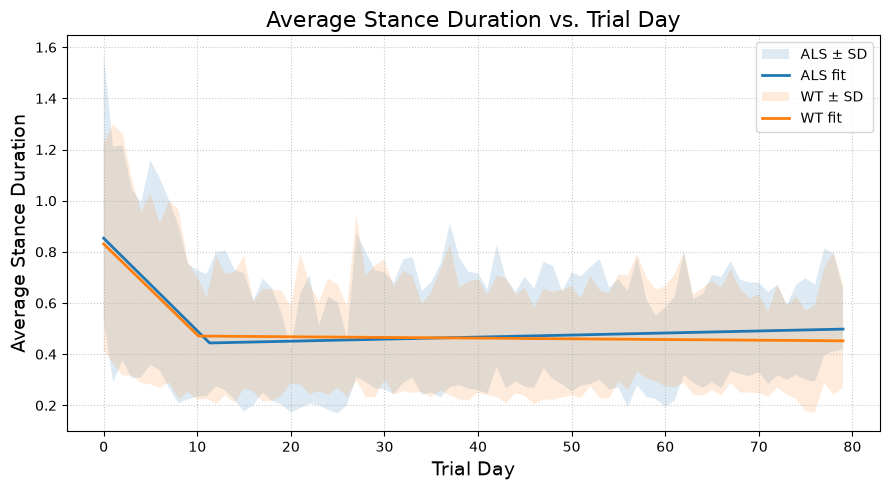

average_stance_duration ALS slopes: [-0.0362  0.0008] WT slopes: [-0.0355 -0.0003]


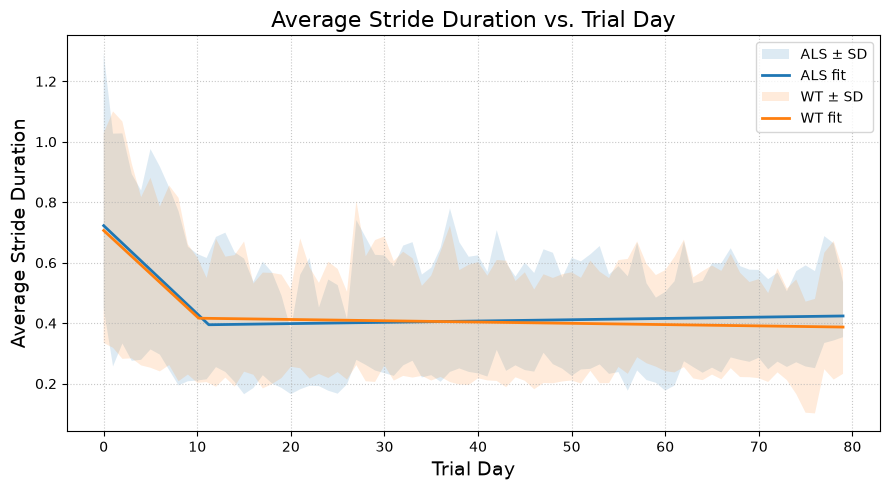

average_stride_duration ALS slopes: [-0.0292  0.0004] WT slopes: [-0.0286 -0.0004]


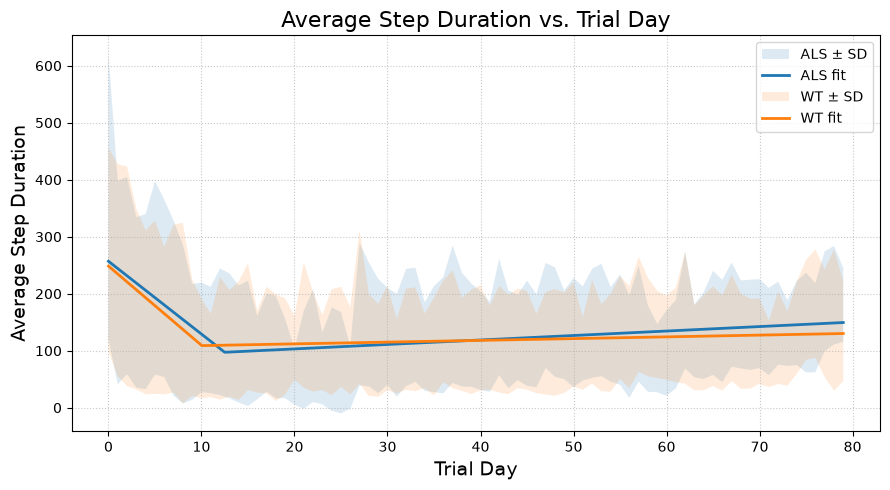

average_step_duration ALS slopes: [-12.7761   0.7842] WT slopes: [-13.8924   0.3073]


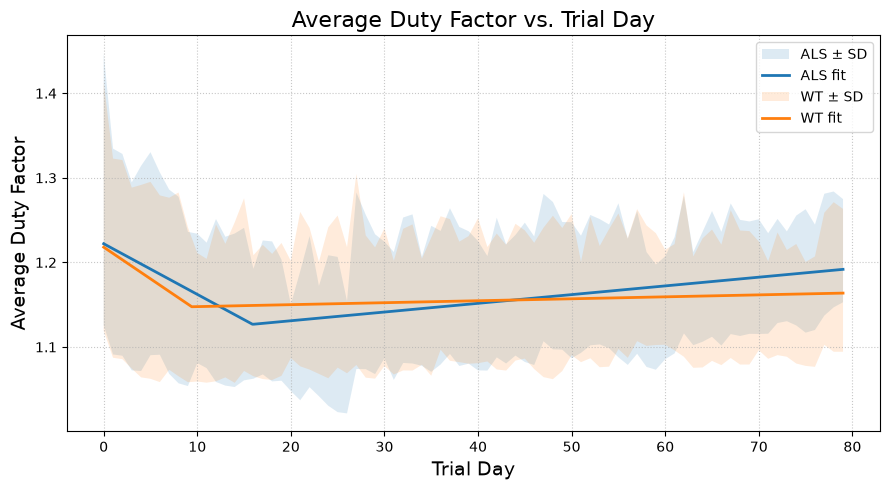

average_duty_factor ALS slopes: [-0.006  0.001] WT slopes: [-0.0075  0.0002]


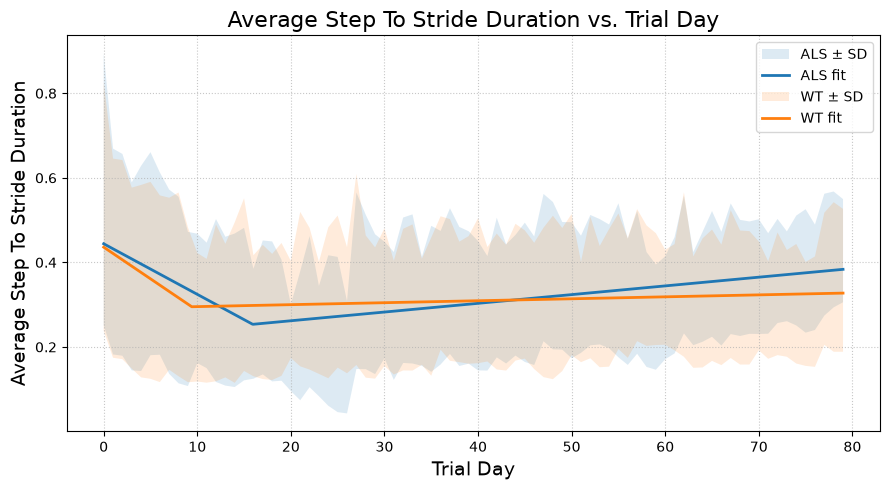

average_step_to_stride_duration ALS slopes: [-0.012   0.0021] WT slopes: [-0.015   0.0005]


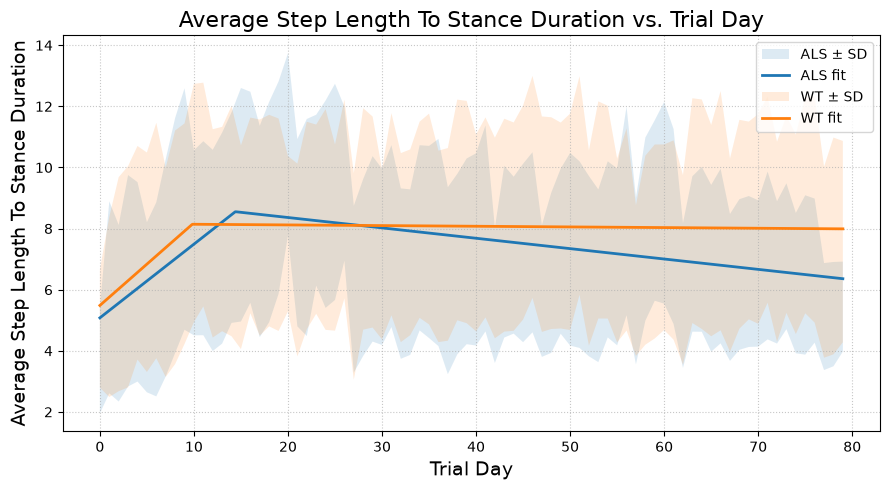

average_step_length_to_stance_duration ALS slopes: [ 0.2412 -0.034 ] WT slopes: [ 0.2703 -0.0022]


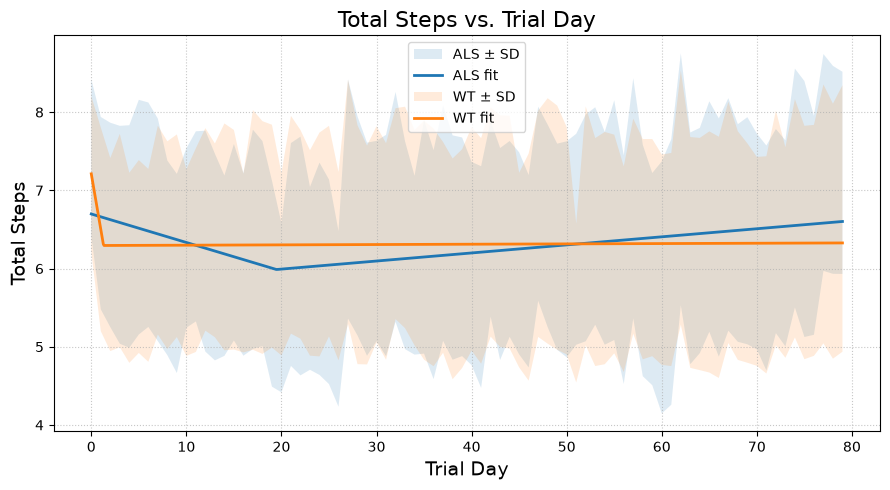

total_steps ALS slopes: [-0.0365  0.0103] WT slopes: [-7.099e-01  4.000e-04]


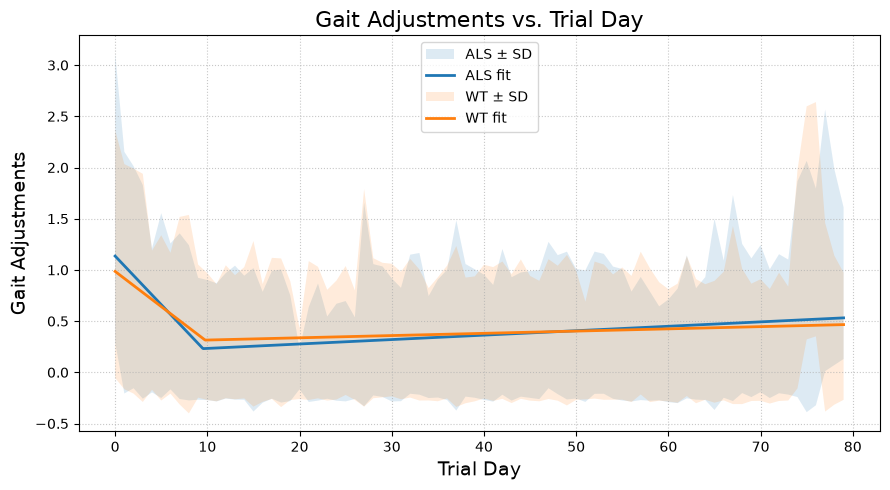

gait_adjustments ALS slopes: [-0.0949  0.0043] WT slopes: [-0.0687  0.0022]


In [13]:
if not analysis_df.empty:
    output_dir = Path('figures/generated')
    output_dir.mkdir(parents=True, exist_ok=True)
    for var in measurements:
        if var == 'average_step_length':
            continue
        # This is the same setup as hengen_ALS_WT.py, repeated for each original metric.
        df = analysis_df[['trial_day', 'genotype', var]]
        df = df[df['trial_day'] < 80]
        stats = (df.groupby(['trial_day', 'genotype'])[var]
                   .agg(['mean', 'std']).reset_index())
        plt.figure(figsize=(9, 5))
        breaks_ALS, slopes_ALS = fit_piecewise('ALS', n_segments=2)
        breaks_WT, slopes_WT = fit_piecewise('WT', n_segments=2)
        title = var.replace('_', ' ').title()
        plt.title(f'{title} vs. Trial Day', fontsize=16)
        plt.xlabel('Trial Day', fontsize=14)
        plt.ylabel(title, fontsize=14)
        plt.grid(True, which='both', linestyle=':', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.savefig(output_dir / f'{var}.png', dpi=160)
        plt.show()
        print(var, 'ALS slopes:', np.round(slopes_ALS, 4),
              'WT slopes:', np.round(slopes_WT, 4))

## 7. Conclusion

**Step Speed vs. Trial Day** was the most sensitive indicator of ALS motor decline.
